In [9]:
!pip install numpy torchaudio soundfile matplotlib torch pyaudio


[notice] A new release of pip is available: 24.0 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [10]:
import io
import numpy as np
import torch

torch.set_num_threads(1)
import torchaudio
import matplotlib
import matplotlib.pylab as plt

torchaudio.set_audio_backend("soundfile")
import pyaudio

/var/folders/6c/wp2ljx192772gwj55m376s4w0000gn/T/ipykernel_78141/1351276638.py:10: UserWarning: torchaudio._backend.set_audio_backend has been deprecated. With dispatcher enabled, this function is no-op. You can remove the function call.
  torchaudio.set_audio_backend("soundfile")


In [11]:
vad_model, utils = torch.hub.load(
    repo_or_dir="snakers4/silero-vad", model="silero_vad", force_reload=True
)

Downloading: "https://github.com/snakers4/silero-vad/zipball/master" to /Users/filipnowak/.cache/torch/hub/master.zip


In [12]:
(get_speech_timestamps, save_audio, read_audio, VADIterator, collect_chunks) = utils

In [13]:
# Taken from utils_vad.py
def validate(model, inputs: torch.Tensor):
    with torch.no_grad():
        outs = model(inputs)
    return outs


# Provided by Alexander Veysov
def int2float(sound):
    abs_max = np.abs(sound).max()
    sound = sound.astype("float32")
    if abs_max > 0:
        sound *= 1 / 32768
    sound = sound.squeeze()  # depends on the use case
    return sound

In [14]:
FORMAT = pyaudio.paInt16
CHANNELS = 1
SAMPLE_RATE = 16000
CHUNK = int(SAMPLE_RATE / 10)

audio = pyaudio.PyAudio()

In [15]:
# import pyaudio
# import numpy as np
# import torch
# import matplotlib.pyplot as plt
# import wave

# # Constants
# FORMAT = pyaudio.paInt16
# CHANNELS = 1
# SAMPLE_RATE = 16000
# CHUNK = 1024
# num_samples = 512

# # Initialize PyAudio
# audio = pyaudio.PyAudio()

# # Open audio stream
# stream = audio.open(
#     format=FORMAT,
#     channels=CHANNELS,
#     rate=SAMPLE_RATE,
#     input=True,
#     frames_per_buffer=CHUNK,
# )

# data = []
# voiced_confidences = []

# print("Started Recording")
# for i in range(0, 512):
#     audio_chunk = stream.read(num_samples)
#     data.append(audio_chunk)

#     audio_int16 = np.frombuffer(audio_chunk, np.int16)
#     audio_float32 = int2float(audio_int16)

#     # Assuming 'model' is defined elsewhere
#     new_confidence = model(torch.from_numpy(audio_float32), 16000).item()
#     voiced_confidences.append(new_confidence)

# print("Stopped the recording")

# # Close the stream
# stream.stop_stream()
# stream.close()
# audio.terminate()

# # Plot the confidences
# plt.figure(figsize=(20, 6))
# plt.plot(voiced_confidences)
# plt.title("Voice Activity Detection Confidence")
# plt.xlabel("Frame")
# plt.ylabel("Confidence")
# plt.show()

# # Save the recorded audio
# output_filename = "recorded_audio.wav"
# wf = wave.open(output_filename, "wb")
# wf.setnchannels(CHANNELS)
# wf.setsampwidth(audio.get_sample_size(FORMAT))
# wf.setframerate(SAMPLE_RATE)
# wf.writeframes(b"".join(data))
# wf.close()

# print(f"Audio saved as {output_filename}")


# import torch
# from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline
# from datasets import load_dataset


# device = "cuda:0" if torch.cuda.is_available() else "cpu"
# torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

# model_id = "openai/whisper-large-v3-turbo"

# model = AutoModelForSpeechSeq2Seq.from_pretrained(
#     model_id, torch_dtype=torch_dtype, low_cpu_mem_usage=True, use_safetensors=True
# )
# model.to(device)

# processor = AutoProcessor.from_pretrained(model_id)

# pipe = pipeline(
#     "automatic-speech-recognition",
#     model=model,
#     tokenizer=processor.tokenizer,
#     feature_extractor=processor.feature_extractor,
#     torch_dtype=torch_dtype,
#     device=device,
# )

# dataset = load_dataset("distil-whisper/librispeech_long", "clean", split="validation")
# sample = dataset[0]["audio"]

# result = pipe(sample)
# print(result["text"])

Started Recording for 10 seconds


OSError: [Errno -9981] Input overflowed

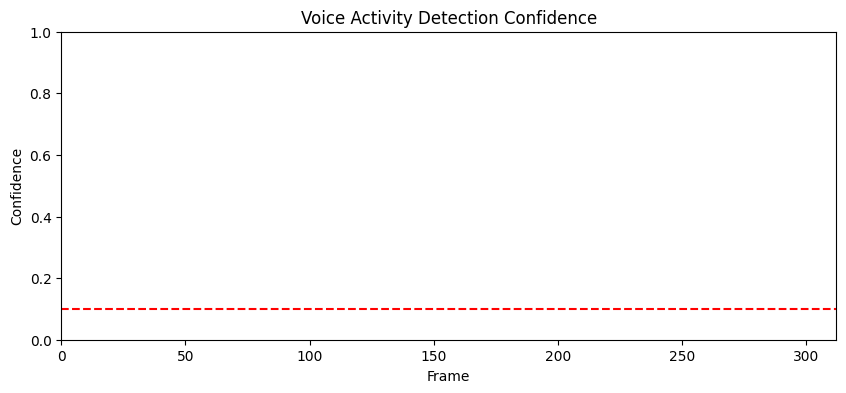

In [19]:
import pyaudio
import numpy as np
import torch
import matplotlib.pyplot as plt
import wave
import ipywidgets as widgets
from IPython.display import display, clear_output
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor, pipeline
import time
import sounddevice as sd

# Constants
FORMAT = pyaudio.paInt16
CHANNELS = 1
SAMPLE_RATE = 16000
CHUNK = 1024
num_samples = 512
VAD_THRESHOLD = 0.1  # Adjust this threshold as needed
RECORD_SECONDS = 10  # Recording duration

# Initialize PyAudio
audio = pyaudio.PyAudio()

# Open audio stream
stream = audio.open(
    format=FORMAT,
    channels=CHANNELS,
    rate=SAMPLE_RATE,
    input=True,
    frames_per_buffer=CHUNK,
)

# Initialize Whisper model
device = "cuda:0" if torch.cuda.is_available() else "cpu"
torch_dtype = torch.float16 if torch.cuda.is_available() else torch.float32
model_id = "openai/whisper-large-v3-turbo"
model = AutoModelForSpeechSeq2Seq.from_pretrained(
    model_id, torch_dtype=torch_dtype, low_cpu_mem_usage=True, use_safetensors=True
)
model.to(device)
processor = AutoProcessor.from_pretrained(model_id)
pipe = pipeline(
    "automatic-speech-recognition",
    model=model,
    tokenizer=processor.tokenizer,
    feature_extractor=processor.feature_extractor,
    torch_dtype=torch_dtype,
    device=device,
)


def int2float(sound):
    abs_max = np.abs(sound).max()
    sound = sound.astype("float32")
    if abs_max > 0:
        sound *= 1 / 32768
    sound = sound.squeeze()
    return sound


# Simple energy-based VAD
def vad_model(audio, sample_rate):
    return np.mean(np.abs(audio))


# Setup for real-time plotting
plt.ion()
fig, ax = plt.subplots(figsize=(10, 4))
(line,) = ax.plot([], [])
ax.set_ylim(0, 1)
ax.set_xlim(0, RECORD_SECONDS * SAMPLE_RATE // num_samples)
ax.set_title("Voice Activity Detection Confidence")
ax.set_xlabel("Frame")
ax.set_ylabel("Confidence")
ax.axhline(y=VAD_THRESHOLD, color="r", linestyle="--")


# Function to play audio
def play_audio(filename):
    wf = wave.open(filename, "rb")
    data = wf.readframes(wf.getnframes())
    audio_np = np.frombuffer(data, dtype=np.int16)
    sd.play(audio_np, wf.getframerate())
    sd.wait()
    wf.close()


data = []
voiced_confidences = []
is_transcribing = False
transcription_buffer = []

print("Started Recording for", RECORD_SECONDS, "seconds")
start_time = time.time()

try:
    while time.time() - start_time < RECORD_SECONDS:
        audio_chunk = stream.read(num_samples)
        audio_int16 = np.frombuffer(audio_chunk, np.int16)
        audio_float32 = int2float(audio_int16)

        # Voice activity detection
        vad_confidence = vad_model(audio_float32, SAMPLE_RATE)
        voiced_confidences.append(vad_confidence)
        print("VAD Confidence:", vad_confidence)

        if vad_confidence > VAD_THRESHOLD:
            if not is_transcribing:
                print("Voice detected, starting transcription...")
                is_transcribing = True
            transcription_buffer.append(audio_chunk)
        elif is_transcribing:
            print("Voice ended, transcribing...")
            is_transcribing = False

            # Combine audio chunks and transcribe
            full_audio = b"".join(transcription_buffer)
            audio_np = np.frombuffer(full_audio, np.int16).astype(np.float32) / 32768.0
            result = pipe(audio_np, sampling_rate=SAMPLE_RATE)
            print("Transcription:", result["text"])

            # Clear the buffer
            transcription_buffer = []

        data.append(audio_chunk)

        # Update plot
        line.set_data(range(len(voiced_confidences)), voiced_confidences)
        fig.canvas.draw()
        fig.canvas.flush_events()

except KeyboardInterrupt:
    print("Recording stopped early")

print("Recording finished")

# Close the stream
stream.stop_stream()
stream.close()
audio.terminate()

# Save the recorded audio
output_filename = "recorded_audio.wav"
wf = wave.open(output_filename, "wb")
wf.setnchannels(CHANNELS)
wf.setsampwidth(audio.get_sample_size(FORMAT))
wf.setframerate(SAMPLE_RATE)
wf.writeframes(b"".join(data))
wf.close()
print(f"Audio saved as {output_filename}")

# Play the recorded audio
print("Playing recorded audio...")
play_audio(output_filename)

# Final plot
plt.ioff()
plt.figure(figsize=(10, 4))
plt.plot(voiced_confidences)
plt.title("Voice Activity Detection Confidence")
plt.xlabel("Frame")
plt.ylabel("Confidence")
plt.axhline(y=VAD_THRESHOLD, color="r", linestyle="--")
plt.show()